In [5]:
import numpy as np
import pandas as pd
from math import exp
from matplotlib import pyplot, animation
import matplotlib.pyplot as plt
from numpy import sqrt

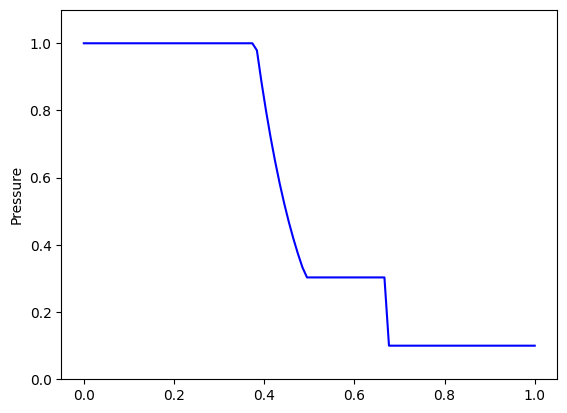

In [6]:
import sodshock
import matplotlib.pyplot as plt
import os

blockstr = os.environ.get('KEEP_FIGURES_OPEN', 'yes')
block = blockstr.lower() in ('1', 'y', 'yes', 'true')
gamma = 1.4
Frac = 0.0
npts = 100
t = 0.2
left = (1,1,0)
right = (0.1, 0.125, 0.)

def Exacte_sol():

    gamma = 1.4
    Frac = 0.0
    npts = 100
    t = 0.1
    left_state = (1,1,0)
    right_state = (0.1, 0.125, 0.)

    positions, regions, values = sodshock.solve(left_state=left, \
        right_state=right, geometry=(0., 1., 0.5), t=t,
        gamma=gamma, npts=npts, dustFrac=Frac)


    plt.plot(values['x'], values['p'], linewidth=1.5, color='b')
    #plt.plot(values['x'], values['rho'], linewidth=1.5, color='g')
    #plt.plot(values['x'], values['u'], linewidth=1.5, color='r')
    plt.ylabel('Pressure')
    plt.ylim(0, 1.1)
    plt.show(block=block)


if __name__ == '__main__':
    Exacte_sol()



In [7]:
def F1(rho, u):
    return rho*u

def F2(rho, u):
    return (rho * u**2) + p

def F3(rho, u, E):
    return rho*u*E + p*u

In [8]:
def Roe(CFL ,k,N, t):

    a = 0
    b = 1
    dx = (b-a) / (N+1)
    p= np.ones(3)

    gamma = 1.4
    rho_new = np.zeros(N+1)
    fluxp_rho = np.zeros(N)
    fluxp_rhou = np.zeros(N)
    fluxp_rhoe = np.zeros(N)
    x  = np.linspace(a+dx/2,b-dx/2,N+1)
    rho = k[0, 0::3]
    E = k[0, 2::3]
    u = k[0, 1::3] / rho
    p = (gamma - 1) * (E - 0.5 * rho * u * u)

    rho = [k(i,0)[0] for i in x]
    u = [k(i,0)[1] for i in x]
    E = [k(i,0)[2] for i in x]

    temps = 0
    rho_hist = [rho.copy()]

    while(temps<t):
        Max = 0
        for i in range(N+1):
            c = np.sqrt(gamma*p/rho)
            Max = max(Max, c)
        delta_t = (CFL*dx)/Max

        for i in range(0,N):

            rho_tilda=[(rho[i]+rho[i+1])/2 for i in range(N)]
            u_tilda=[(np.sqrt(rho[i])*u[i]+np.sqrt(rho[i+1])*u[i+1])/(np.sqrt(rho[i])+np.sqrt(rho[i+1])) for i in range(N)]

            R=[[1,1,1],[u_tilda[i], u_tilda[i]-c, u_tilda[i]+c],[0.5*u*u]]
            D=[[ np.abs(u_tilda[i] ),0, 0],[0,np.abs(u_tilda[i] - c),0],[0,0, np.abs(u_tilda[i] + c)]]
            Rm=[[np.sqrt(c**2)-(0.5*(gamma-1))*(u_tilda[i])**2,(gamma-1)*(u_tilda[i]),1-gamma],[0.25*((gamma-1)*(u_tilda[i])**2+2*(u_tilda[i])*c),0.5*((1-gamma)*(u_tilda[i])-c),0.5* (gamma-1)],[0.25*((gamma-1)*(u_tilda[i])**2 - 2*(u_tilda[i])*c),0.5*((1-gamma)*(u_tilda[i])+c),0.5* (gamma-1)]]
            #vect=[h[i+1]-h[i],h[i+1]*u[i+1]-h[i]*u[i]]
            vect=[rho[i+1]-rho[i],rho[i+1]*u[i+1]-rho[i]*u[i],rho[i+1]*E[i+1]-rho[i]*E[i]]
            coef=1/(2*(c**2))

            p=np.dot(np.dot(np.dot(R,D),Rm),vect)
            fluxp_rho[i] = 0.5*(F1(rho[i], u[i]) + F1(rho[i+1], u[i+1])) -coef*p[0]

            fluxp_rhou[i] = 0.5*(F2(rho[i+1], u[i+1]) + F2(rho[i], u[i])) -coef*p[1]

            fluxp_rhoe[i] = 0.5*(F3(rho[i+1], u[i+1] , E[i+1]) + F3(rho[i], u[i] , E[i])) -coef*p[2]

        for i in range(1,N):
            lamda  = delta_t /dx
            rho_new[i] = rho[i] - lamda*(fluxp_rho[i] - fluxp_rho[i-1])

            rhou = rho[i]*u[i] - lamda*(fluxp_rhou[i] - fluxp_rhou[i-1])
            u[i] = rhou/rho_new[i]

            rhoe = rho[i]*E[i] - lamda*(fluxp_rhoe[i] - fluxp_rhoe[i-1])
            u[i] = rhoe/rho_new[i]

        rho = rho_new.copy()
        # Applying boundary conditions.
        rho[0] = rho[1]
        u[0] = u[1]
        E[0] = E[1]
        E[N] = E[N-1]
        rho[N] = rho[N-1]
        u[N] = u[N-1]
        temps = temps +delta_t

    return rho,u

